# Client 2 : Modèle de classification de l'âge estimé

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              RocCurveDisplay, roc_curve)
from scipy.stats import randint

## Import des données

In [199]:
df_raw = pd.read_csv('../../data/Data_Arbre_Clean.csv')
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10418 entries, 0 to 10417
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   X               10418 non-null  float64
 1   Y               10418 non-null  float64
 2   clc_quartier    9933 non-null   str    
 3   clc_secteur     10415 non-null  str    
 4   id_arbre        10399 non-null  float64
 5   haut_tot        10418 non-null  float64
 6   haut_tronc      10418 non-null  float64
 7   tronc_diam      10405 non-null  float64
 8   fk_arb_etat     10418 non-null  str    
 9   fk_stadedev     9331 non-null   str    
 10  fk_port         10273 non-null  str    
 11  fk_pied         10297 non-null  str    
 12  fk_situation    10417 non-null  str    
 13  fk_revetement   9461 non-null   object 
 14  dte_plantation  610 non-null    str    
 15  age_estim       10415 non-null  float64
 16  clc_nbr_diag    8312 non-null   float64
 17  dte_abattage    778 non-null    str    
 1

In [200]:
df_raw.head()

,X,Y,clc_quartier,clc_secteur,id_arbre,haut_tot,haut_tronc,tronc_diam,fk_arb_etat,fk_stadedev,...,fk_revetement,dte_plantation,age_estim,clc_nbr_diag,dte_abattage,villeca,nomfrancais,nomlatin,feuillage,remarquable
0,1.720320e+06,8.294619e+06,Quartier du Centre-Ville,Boulevard Richelieu,24.0,0.0,0.0,0.0,SUPPRIMÉ,NaN,...,NaN,NaN,0.0,0.0,2015-07-01T00:00:00Z,VILLE,NaN,NaN,NaN,False
1,1.720898e+06,8.293531e+06,Quartier du Centre-Ville,Boulevard Léon Blum,24.0,0.0,0.0,0.0,ABATTU,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False
2,1.720894e+06,8.293542e+06,Quartier du Centre-Ville,Boulevard Léon Blum,53.0,0.0,0.0,0.0,SUPPRIMÉ,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False
3,1.720902e+06,8.293545e+06,Quartier du Centre-Ville,Boulevard Léon Blum,54.0,0.0,0.0,0.0,SUPPRIMÉ,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False
4,1.721089e+06,8.293619e+06,Quartier du Centre-Ville,Boulevard Léon Blum,63.0,0.0,0.0,0.0,ABATTU,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False


## Création des classes d'âge

On transforme la variable age_estim en 4 classes (Jeune, Jeune Adulte, Adulte, Vieux) :

In [201]:
bins   = [0, 15, 30, 50, 200]
labels = ['Jeune (0-15)', 'Jeune adulte (15-30)', 'Adulte (30-50)', 'Vieux (50+)']

df_raw['age_classe'] = pd.cut(df_raw['age_estim'], bins=bins, labels=labels, include_lowest=True)

df_raw['age_classe'].value_counts().sort_index()

age_classe
Jeune (0-15)            3396
Jeune adulte (15-30)    2548
Adulte (30-50)          3814
Vieux (50+)              657
Name: count, dtype: int64

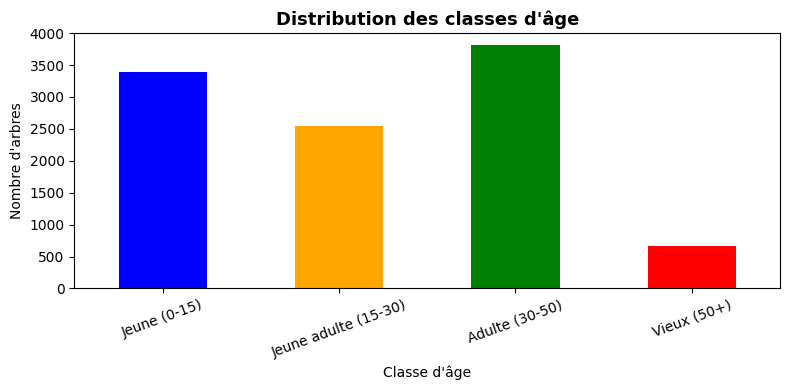

In [202]:
plt.figure(figsize=(8, 4))
df_raw['age_classe'].value_counts().sort_index().plot(kind='bar', color=['blue','orange','green','red'])
plt.title("Distribution des classes d'âge", fontsize=13, fontweight='bold')
plt.xlabel("Classe d'âge")
plt.ylabel("Nombre d'arbres")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Sélection et préparation des features

In [203]:
# Valeurs numériques
col_num = ['haut_tot', 'haut_tronc', 'tronc_diam']

# Valeurs qualitatives
col_qual = ['fk_stadedev', 'nomlatin']

# Filtrage
df = df_raw[col_num + col_qual + ['age_classe'] + ['age_estim']].copy()
df = df.dropna(subset=['age_classe'])

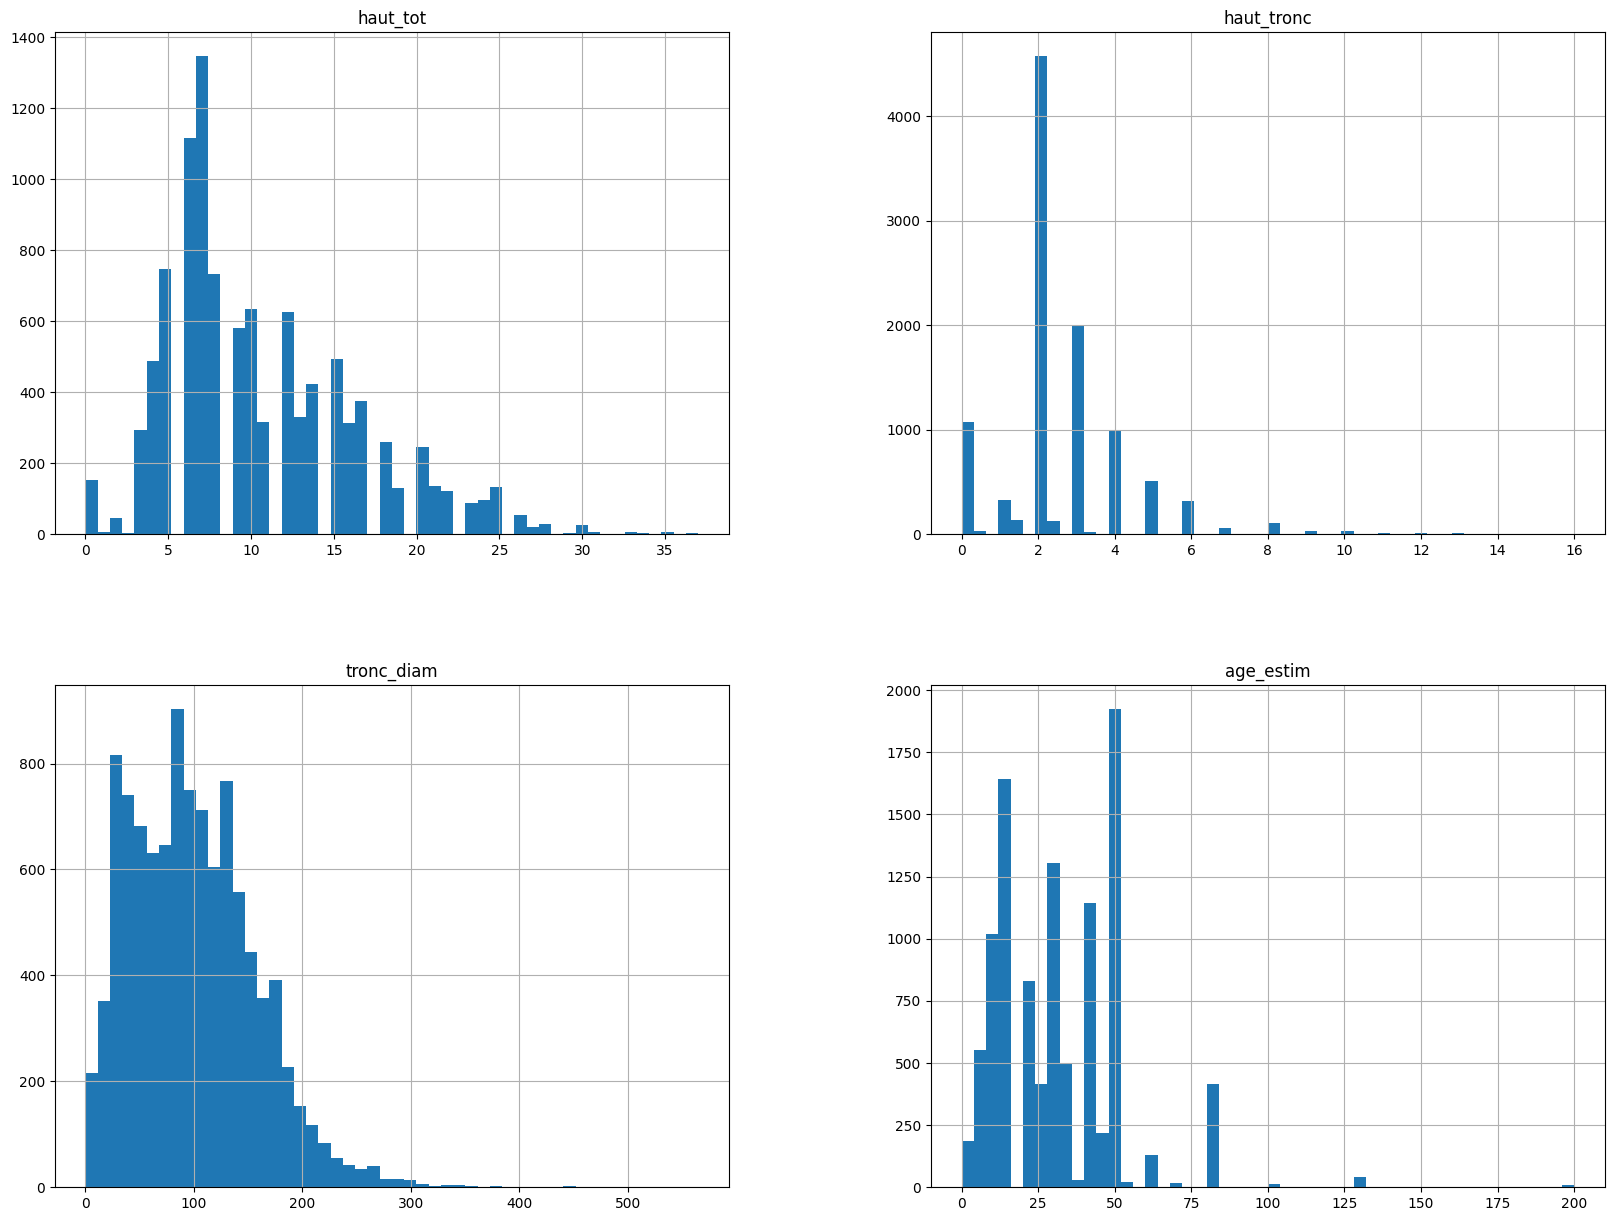

In [204]:
df.hist(bins=50, figsize=(20,15))
plt.show()

> On remarque que les données sont plutôt bien réparties cependant il y a beaucoup de valeurs manquantes

## Feature Engineering

In [205]:
# Ratio diamètre / hauteur
df['diam_haut_ratio'] = df['tronc_diam'] / (df['haut_tot'] + 1)

col_num_ext = col_num + ['diam_haut_ratio']

## Matrice de corrélation

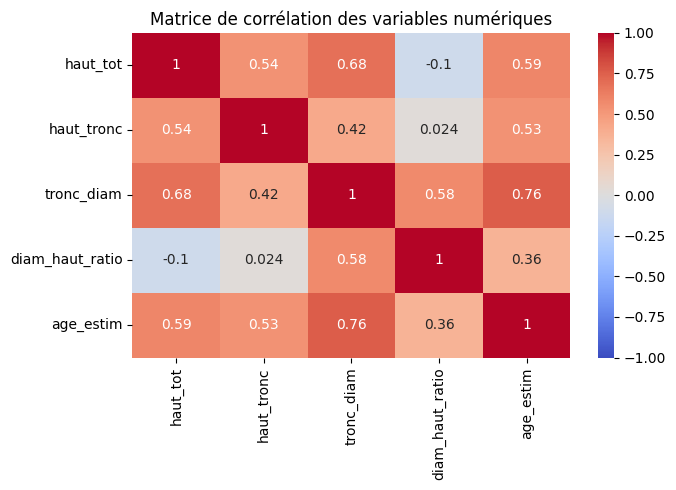

In [206]:
corr_matrix = df[col_num_ext + ['age_estim']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matrice de corrélation des variables numériques')
plt.tight_layout()
plt.show()

> On retrouve des données similaires à la partie big data avec l'âge qui est principalement influencé par le diamètre du tronc puis par la hauteur totale et de son tronc

In [207]:
# On retire l'âge estimé
df.drop('age_estim', axis=1, inplace=True)

## Prétraitement des colonnes

In [208]:
# Remplacement des valeurs manquantes par la mediane
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Remplacement des valeurs manquantes par la valeur la plus fréquente
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, col_num_ext),
    ('cat', cat_pipeline, col_qual)
])

## Split train / test

In [209]:
# Valeurs explicatives 
X = df[col_num_ext + col_qual]
# Valeur cible
y = df['age_classe']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modélisation

## Régression Logistique

In [210]:
model_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42))
])
model_lr.fit(X_train, y_train)

/opt/miniconda3/envs/projet_ia_web_bd/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Arbre de Décision

In [211]:
model_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])
model_dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Random Forest

In [212]:
model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])
model_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Comparaison des modèles

In [213]:
from sklearn.metrics import accuracy_score, f1_score

model_dict = {
    "Logistic Regression"    : model_lr,
    "Decision Tree"          : model_dt,
    "Random Forest"          : model_rf,
}

results = []
for name, model in model_dict.items():
    y_pred = model.predict(X_test)
    results.append({
        "Modèle"      : name,
        "Accuracy"    : accuracy_score(y_test, y_pred),
        "F1 (macro)"  : f1_score(y_test, y_pred, average='macro'),
    })

df_results = pd.DataFrame(results).sort_values("F1 (macro)", ascending=False)
df_results

,Modèle,Accuracy,F1 (macro)
2,Random Forest,0.845895,0.845015
1,Decision Tree,0.815651,0.806439
0,Logistic Regression,0.732117,0.692873


/tmp/ipykernel_110499/2586296911.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


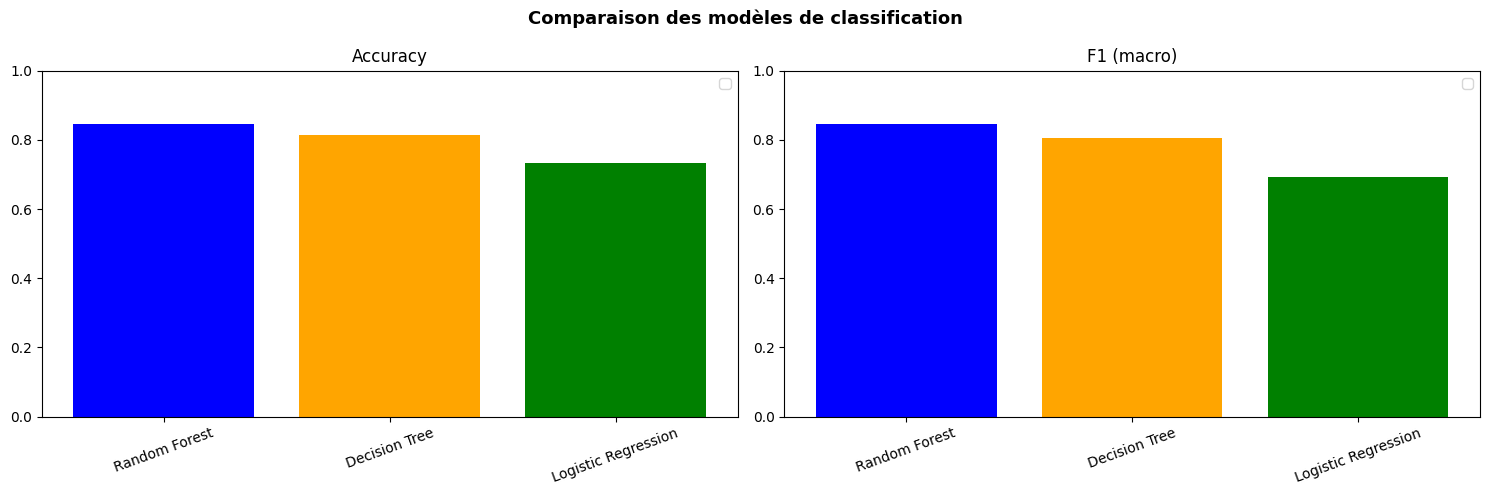

In [214]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ['blue', 'orange', 'green', 'red']

for ax, metric in zip(axes, ["Accuracy", "F1 (macro)"]):
    ax.bar(df_results["Modèle"], df_results[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    ax.legend()

plt.suptitle("Comparaison des modèles de classification", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> On remarque que Random Forest possède la meilleure accuracy et le plus haut score, suivi par le decision tree puis la régression logistique

## Matrices de confusion

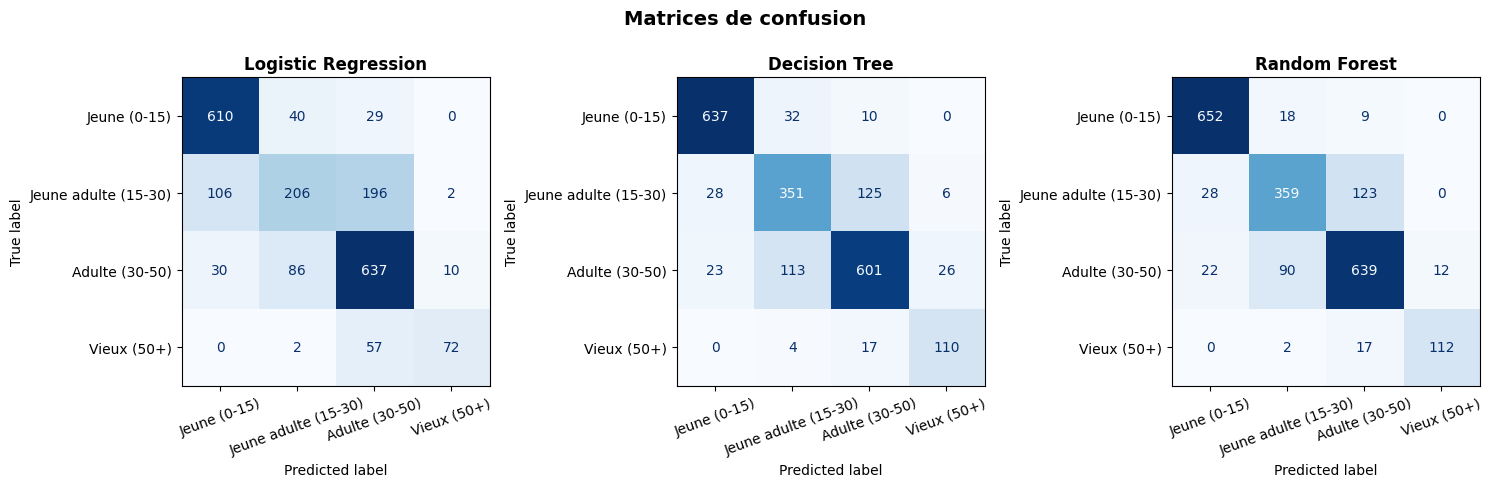

In [215]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
class_names = [str(l) for l in labels]

for ax, (name, model) in zip(axes.flat, model_dict.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Matrices de confusion", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> On remarque que l'algorithme confond Jeune Adulte et Adulte cependant Random Forest semble mieux se débrouiller

## Rapports de classification détaillés

In [216]:
for name, model in model_dict.items():
    y_pred = model.predict(X_test)
    print(f"Modèle : {name}")
    print(classification_report(y_test, y_pred, target_names=class_names))

Modèle : Logistic Regression
                      precision    recall  f1-score   support

        Jeune (0-15)       0.69      0.83      0.76       763
Jeune adulte (15-30)       0.82      0.90      0.86       679
      Adulte (30-50)       0.62      0.40      0.49       510
         Vieux (50+)       0.86      0.55      0.67       131

            accuracy                           0.73      2083
           macro avg       0.75      0.67      0.69      2083
        weighted avg       0.73      0.73      0.72      2083

Modèle : Decision Tree
                      precision    recall  f1-score   support

        Jeune (0-15)       0.80      0.79      0.79       763
Jeune adulte (15-30)       0.93      0.94      0.93       679
      Adulte (30-50)       0.70      0.69      0.70       510
         Vieux (50+)       0.77      0.84      0.81       131

            accuracy                           0.82      2083
           macro avg       0.80      0.81      0.81      2083
        weigh

In [217]:
pipe_rf = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist = {
    'model__n_estimators'      : randint(100, 500),
    'model__max_depth'         : [None, 10, 20, 30],
    'model__min_samples_split' : randint(2, 10),
    'model__min_samples_leaf'  : randint(1, 5),
    'model__max_features'      : ['sqrt', 'log2'],
    'model__class_weight'      : [None, 'balanced'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    pipe_rf, param_dist,
    n_iter=40, cv=cv,
    scoring='f1_macro',
    n_jobs=-1, random_state=42, verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/opt/miniconda3/envs/projet_ia_web_bd/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/miniconda3/envs/projet_ia_web_bd/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/miniconda3/envs/projet_ia_web_bd/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/miniconda3/envs/projet_

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': <scipy.stats....x7f4174443cf0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the va

In [218]:
print(f"Meilleurs paramètres : {random_search.best_params_}")

Meilleurs paramètres : {'model__class_weight': None, 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 8, 'model__n_estimators': 108}


In [219]:
best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=class_names))

print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1 macro  : {f1_score(y_test, y_pred_best, average='macro'):.4f}")

                      precision    recall  f1-score   support

        Jeune (0-15)       0.81      0.87      0.84       763
Jeune adulte (15-30)       0.93      0.96      0.95       679
      Adulte (30-50)       0.79      0.69      0.74       510
         Vieux (50+)       0.94      0.83      0.88       131

            accuracy                           0.85      2083
           macro avg       0.87      0.84      0.85      2083
        weighted avg       0.85      0.85      0.85      2083

Accuracy  : 0.8541
F1 macro  : 0.8514


## Importance des variables

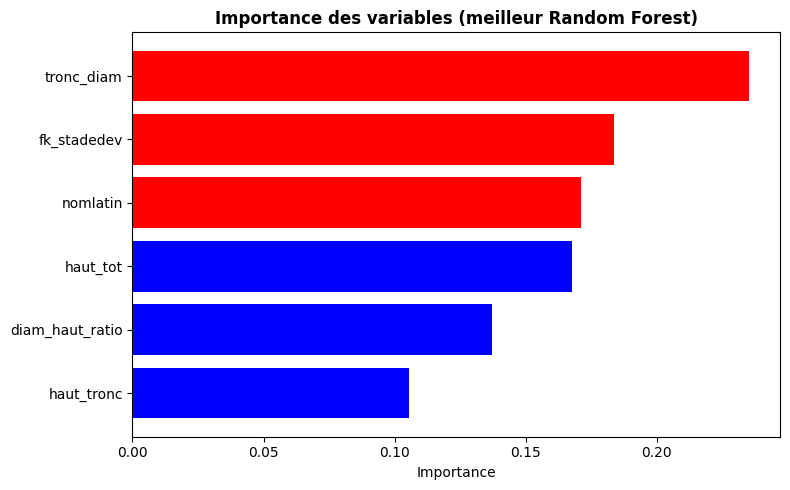

In [220]:
feature_names = col_num_ext + col_qual
importances   = best_model.named_steps['model'].feature_importances_
df_imp = (pd.DataFrame({'feature': feature_names, 'importance': importances})
            .sort_values('importance', ascending=True))

median_imp = df_imp['importance'].median()
colors_imp = ['red' if v > median_imp else 'blue' for v in df_imp['importance']]

plt.figure(figsize=(8, 5))
plt.barh(df_imp['feature'], df_imp['importance'], color=colors_imp)
plt.xlabel('Importance')
plt.title('Importance des variables (meilleur Random Forest)', fontweight='bold')
plt.tight_layout()
plt.show()

> On remarque que le diamètre du tronc joue un rôle majeur dans la prédiction de l'age de l'arbre, d'autres variables comme le stade de dev de l'arbre et le nom latin et sa hauteur influencent aussi à plus petite échelle. On retrouve donc des estimations cohérentes avec la partie Big Data

# Sauvegarde

In [221]:
joblib.dump(best_model, 'model_age_classification.pkl')
print("Modèle sauvegardé : model_age_classification.pkl")

Modèle sauvegardé : model_age_classification.pkl


# Chargement et prédiction sur un nouvel arbre

In [222]:
arbre = pd.DataFrame([{
    'haut_tot'        : 10.0,
    'haut_tronc'      : 2.0,
    'tronc_diam'      : 150.0,
    'fk_stadedev'     : 'adulte',
    'nomlatin'        : 'TILCOR',
}])

# diam haut ratio
arbre['diam_haut_ratio'] = arbre['tronc_diam'] / arbre['haut_tot']

model = joblib.load('model_age_classification.pkl')
prediction       = model.predict(arbre)[0]
probabilities    = model.predict_proba(arbre)[0]

# Confiance de la prédiction
print("Probabilités par classe :")
for cls, prob in zip(model.classes_, probabilities):
    print(f"  {cls} : {prob:.1%}")

Probabilités par classe :
  Adulte (30-50) : 93.3%
  Jeune (0-15) : 0.0%
  Jeune adulte (15-30) : 4.0%
  Vieux (50+) : 2.7%
